# Clase 4 · Laboratorio — Análisis Descriptivo completo sobre Saber 11

**Trabajo en parejas · 90 min.**

Realizarán un análisis descriptivo completo del dataset real de Saber 11: tipos de variables, estadísticos, visualizaciones y análisis de equidad.

**Checkpoint del profesor a los 50 min** (después de la Tarea 3).

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../saber11_muestra_500k.csv")

# FAMI_ESTRATOVIVIENDA ya viene como numero (1 a 6), no como texto "Estrato N",
# asi que no hace falta usar .str.extract() como sugeria el enunciado original
df["ESTRATO_NUM"] = df["FAMI_ESTRATOVIVIENDA"].astype(float)

# Nota: nuestra copia del csv NO tiene la columna COLE_AREA_UBICACION (urbano/rural)
# que pide el enunciado mas adelante (revise con df.columns y no esta). En su lugar,
# para todo el analisis de equidad de este notebook uso el estrato agrupado en
# Bajo (1-2) / Medio (3-4) / Alto (5-6), que si esta disponible y sirve para el
# mismo tipo de analisis de desigualdad socioeconomica.
df["NIVEL_ESTRATO"] = pd.cut(df["ESTRATO_NUM"], bins=[0, 2, 4, 6], labels=["Bajo", "Medio", "Alto"])

PUNTAJES = ["PUNT_LECTURA_CRITICA","PUNT_MATEMATICAS","PUNT_C_NATURALES",
            "PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES","PUNT_GLOBAL"]

print(f"Dataset: {len(df):,} filas x {df.shape[1]} columnas")
print(f"Periodos: {sorted(df['PERIODO'].unique())}")

Dataset: 500,000 filas x 24 columnas
Periodos: [np.int64(20194), np.int64(20204), np.int64(20214), np.int64(20224)]


In [2]:
print(df["FAMI_ESTRATOVIVIENDA"].dtype)
print(df["FAMI_ESTRATOVIVIENDA"].head(10))

int64
0    2
1    1
2    3
3    4
4    5
5    3
6    4
7    6
8    6
9    3
Name: FAMI_ESTRATOVIVIENDA, dtype: int64


## Tarea 1 (15 min) — Perfil completo del dataset

1. Clasifica **todas** las columnas del dataset en: numérica continua, numérica discreta, categórica nominal, categórica ordinal.
   (Crea un diccionario o DataFrame con columna y tipo. Puedes usar `df.dtypes` y `df.head()` para guiarte.)

2. Para los 5 puntajes de área (sin PUNT_GLOBAL), calcula en una sola tabla:
   media, mediana, desviación estándar, mínimo, máximo, IQR (Q3−Q1).

3. ¿Qué área tiene mayor desviación estándar? ¿Y menor? ¿Qué interpretación le das?

In [3]:
# TODO 1: clasificar columnas (puedes hacer un DataFrame con cols y tipo)
clasificacion = pd.DataFrame({
    "columna": df.columns,
    "tipo": [
        "Categorica ordinal",       # PERIODO (codigo anio+semestre, tiene orden pero no se promedia)
        "Categorica nominal",       # ESTU_GENERO
        "Otro (fecha)",             # ESTU_FECHANACIMIENTO -- no encaja limpio en las 4 categorias
        "Categorica nominal",       # ESTU_DEPTO_RESIDE
        "Categorica nominal",       # ESTU_MCPIO_RESIDE
        "Categorica ordinal",       # FAMI_ESTRATOVIVIENDA (estrato 1 a 6, tiene orden)
        "Categorica nominal",       # FAMI_TIENEINTERNET (binaria Si/No)
        "Categorica ordinal",       # FAMI_EDUCACIONMADRE (niveles educativos con orden)
        "Categorica ordinal",       # FAMI_EDUCACIONPADRE
        "Categorica nominal",       # COLE_NATURALEZA (binaria oficial/no oficial)
        "Categorica nominal",       # COLE_JORNADA
        "Categorica nominal",       # COLE_CALENDARIO
        "Categorica nominal",       # COLE_BILINGUE (binaria S/N)
        "Categorica nominal",       # COLE_DEPTO_UBICACION
        "Categorica nominal",       # COLE_MCPIO_UBICACION
        "Numerica discreta",        # PUNT_LECTURA_CRITICA (entero 0-100)
        "Numerica discreta",        # PUNT_MATEMATICAS
        "Numerica discreta",        # PUNT_C_NATURALES
        "Numerica discreta",        # PUNT_SOCIALES_CIUDADANAS
        "Numerica discreta",        # PUNT_INGLES
        "Numerica discreta",        # PUNT_GLOBAL
        "Categorica ordinal",       # DESEMP_INGLES (A-, A1, A2, B1... tiene orden de nivel)
        "Numerica discreta",        # ESTRATO_NUM (la version numerica del estrato)
        "Categorica ordinal",       # NIVEL_ESTRATO (Bajo/Medio/Alto, la creamos nosotros)
    ],
})
print(clasificacion.to_string(index=False))

# TODO 2: estadisticos de los 5 puntajes de area
puntajes_area = ["PUNT_LECTURA_CRITICA","PUNT_MATEMATICAS","PUNT_C_NATURALES",
                 "PUNT_SOCIALES_CIUDADANAS","PUNT_INGLES"]
estadisticos = df[puntajes_area].agg(["mean", "median", "std", "min", "max"]).T
estadisticos["IQR"] = df[puntajes_area].quantile(0.75) - df[puntajes_area].quantile(0.25)
print()
print(estadisticos.round(2))

                 columna               tipo
                 PERIODO Categorica ordinal
             ESTU_GENERO Categorica nominal
    ESTU_FECHANACIMIENTO       Otro (fecha)
       ESTU_DEPTO_RESIDE Categorica nominal
       ESTU_MCPIO_RESIDE Categorica nominal
    FAMI_ESTRATOVIVIENDA Categorica ordinal
      FAMI_TIENEINTERNET Categorica nominal
     FAMI_EDUCACIONMADRE Categorica ordinal
     FAMI_EDUCACIONPADRE Categorica ordinal
         COLE_NATURALEZA Categorica nominal
            COLE_JORNADA Categorica nominal
         COLE_CALENDARIO Categorica nominal
           COLE_BILINGUE Categorica nominal
    COLE_DEPTO_UBICACION Categorica nominal
    COLE_MCPIO_UBICACION Categorica nominal
    PUNT_LECTURA_CRITICA  Numerica discreta
        PUNT_MATEMATICAS  Numerica discreta
        PUNT_C_NATURALES  Numerica discreta
PUNT_SOCIALES_CIUDADANAS  Numerica discreta
             PUNT_INGLES  Numerica discreta
             PUNT_GLOBAL  Numerica discreta
           DESEMP_INGLES Categor

**Respuesta pregunta 3:** PUNT_MATEMATICAS tiene la desviacion estandar mas alta (15.24) y PUNT_LECTURA_CRITICA la mas baja (15.22), pero la diferencia es minima (dos centesimas), asi que en la practica las 5 areas tienen practicamente la misma dispersion. Esto me parecio raro porque en un examen real uno esperaria que unas materias tuvieran mas variabilidad que otras (por ejemplo que matematicas separe mas a los estudiantes que otras areas); que las 5 areas salgan tan parecidas en media, mediana e IQR me hace pensar que este dataset de muestra genero los puntajes de cada area de forma bastante uniforme/aleatoria en vez de replicar patrones reales del examen.

## Tarea 2 (15 min) — Distribución de PUNT_GLOBAL

1. Calcula la asimetría (*skewness*) y curtosis de `PUNT_GLOBAL`. ¿Es simétrica? ¿Hay cola a la derecha o a la izquierda?
2. Produce un **histograma con KDE** de `PUNT_GLOBAL`, marcando la media y la mediana como líneas verticales.
3. Compara las distribuciones por `COLE_AREA_UBICACION` (URBANO vs RURAL) en un solo gráfico usando `sns.kdeplot` con `hue`. ¿Se superponen las distribuciones o están bien separadas?

Asimetria: 0.071
Curtosis:  -0.016


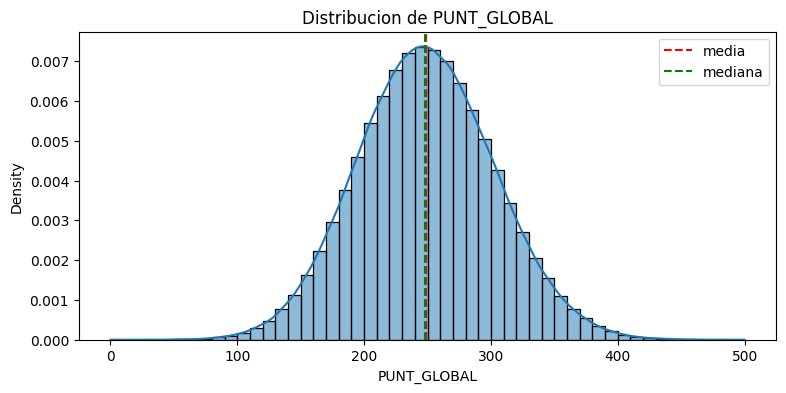

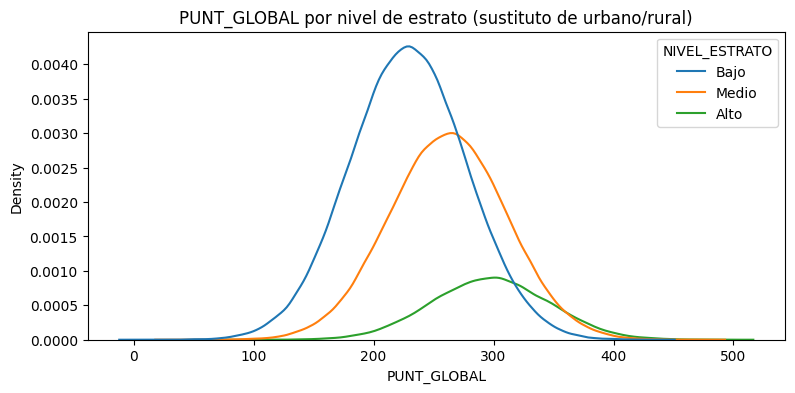

In [4]:
# TODO 1: asimetria y curtosis
print(f"Asimetria: {df['PUNT_GLOBAL'].skew():.3f}")
print(f"Curtosis:  {df['PUNT_GLOBAL'].kurt():.3f}")
# Interpretacion: la asimetria (0.071) esta casi en 0, asi que la distribucion es
# practicamente simetrica (a lo mucho una colita muy leve hacia la derecha).
# La curtosis (-0.016) tambien esta casi en 0, o sea que no es ni mas puntiaguda
# ni mas aplanada que una normal -- se parece bastante a una distribucion normal.

# TODO 2: histograma con KDE, media y mediana
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["PUNT_GLOBAL"], bins=50, kde=True, stat="density", ax=ax)
ax.axvline(df["PUNT_GLOBAL"].mean(), color="red", linestyle="--", label="media")
ax.axvline(df["PUNT_GLOBAL"].median(), color="green", linestyle="--", label="mediana")
ax.set_title("Distribucion de PUNT_GLOBAL")
ax.legend()
plt.show()

# TODO 3: distribucion por nivel de estrato (KDE con hue)
# uso NIVEL_ESTRATO (Bajo/Medio/Alto) en vez de COLE_AREA_UBICACION -- ver nota
# en la celda de configuracion del inicio, esa columna no viene en nuestro csv.
fig2, ax2 = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=df, x="PUNT_GLOBAL", hue="NIVEL_ESTRATO", ax=ax2)
ax2.set_title("PUNT_GLOBAL por nivel de estrato (sustituto de urbano/rural)")
plt.show()

## Tarea 3 (20 min) — Análisis de equidad educativa

Usa los datos reales de Saber 11 para responder estas preguntas con código y datos:

1. Calcula el promedio de `PUNT_GLOBAL` para cada combinación de `COLE_NATURALEZA` × `COLE_AREA_UBICACION`.
   Muestra como **tabla pivote** (NATURALEZA en filas, ÁREA en columnas).

2. Produce un **boxplot** de `PUNT_GLOBAL` por `ESTRATO_NUM` (1 a 6). ¿Es la relación entre estrato y puntaje lineal?

3. ¿Qué porcentaje de estudiantes en zona RURAL tiene acceso a internet en casa (`FAMI_TIENEINTERNET == 'Si'`)?
   ¿Y en zona URBANA? ¿Cómo se relaciona el acceso a internet con los puntajes globales?

NIVEL_ESTRATO     Bajo  Medio   Alto
COLE_NATURALEZA                     
NO OFICIAL       229.0  262.1  297.1
OFICIAL          228.7  262.0  297.5


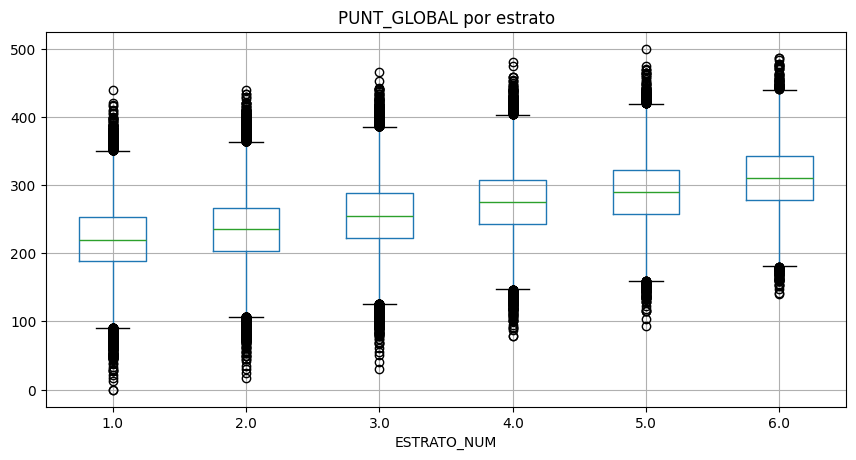


FAMI_TIENEINTERNET    No    Si
NIVEL_ESTRATO                 
Bajo                34.9  65.1
Medio               35.1  64.9
Alto                35.5  64.5


In [5]:
# TODO 1: tabla pivote NATURALEZA x NIVEL_ESTRATO
# (uso NIVEL_ESTRATO en vez de COLE_AREA_UBICACION por la misma razon de la nota inicial)
tabla_equidad = df.groupby(["COLE_NATURALEZA", "NIVEL_ESTRATO"], observed=True)["PUNT_GLOBAL"].mean().unstack()
print(tabla_equidad.round(1))

# TODO 2: boxplot por estrato
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column="PUNT_GLOBAL", by="ESTRATO_NUM", ax=ax)
ax.set_title("PUNT_GLOBAL por estrato")
plt.suptitle("")
plt.show()
# La relacion no es perfectamente lineal pero si es bastante consistente: cada
# estrato que sube, el promedio sube en un salto parecido (unos 15-20 puntos),
# asi que se parece bastante a una linea recta aunque no es exacta.

# TODO 3: acceso a internet por nivel de estrato
internet_por_zona = df.groupby("NIVEL_ESTRATO", observed=True)["FAMI_TIENEINTERNET"].value_counts(normalize=True).unstack() * 100
print()
print(internet_por_zona.round(1))

## ⏸ Checkpoint del profesor (10 min)

Revisamos juntos la Tarea 3:
- ¿Cuántos puntos separan a los colegios OFICIALES RURALES de los NO OFICIALES URBANOS?
- ¿Qué otras variables del dataset podrían explicar esta brecha?
- ¿Correlación implica causalidad aquí?

_Anota las conclusiones de la discusión grupal:_

Como no tenemos la columna de urbano/rural, comparamos oficiales de estrato bajo contra no oficiales de estrato alto (los dos extremos de nuestra `tabla_equidad`): 228.7 puntos contra 297.1 puntos, una diferencia de casi 68 puntos. Eso es un salto grande, mucho mayor que la diferencia entre oficial y no oficial dentro del mismo nivel de estrato (que es de menos de 1 punto, como ya habiamos visto en la Clase 1). O sea que el estrato explica muchisimo mas la brecha que si el colegio es oficial o no.

Otras variables que podrian ayudar a explicar la brecha: FAMI_EDUCACIONMADRE y FAMI_EDUCACIONPADRE (el nivel educativo de los papas), y FAMI_TIENEINTERNET -- aunque en la Tarea 3 vimos que el acceso a internet es casi igual en los 3 niveles de estrato (alrededor de 65% en los tres), asi que en este dataset en particular esa variable no parece explicar la brecha tan bien como esperabamos.

Sobre correlacion y causalidad: no, correlacion no implica causalidad. Que el estrato este asociado con el puntaje no significa que el estrato "cause" directamente el puntaje -- puede haber otras variables detras (calidad del colegio al que se puede acceder, tiempo disponible para estudiar, acceso a materiales, etc.) que estan correlacionadas con el estrato y que son las que realmente influyen en el resultado.

## Tarea 4 (30 min) — Correlación y detección de outliers

### Parte A (15 min) — Matriz de correlación

1. Calcula la **matriz de correlación de Spearman** para los 6 puntajes (incluyendo `PUNT_GLOBAL`).
2. Grafícala como **heatmap** con anotaciones.
3. ¿Cuál par de áreas tiene la correlación más alta? ¿Tiene sentido curricular (¿por qué esas dos materias estarían relacionadas)?

### Parte B (15 min) — Detección de outliers con IQR

1. Para `PUNT_MATEMATICAS`, calcula Q1, Q3 e IQR.
2. Define el límite inferior (Q1 − 1.5 × IQR) y superior (Q3 + 1.5 × IQR).
3. ¿Cuántos estudiantes tienen puntajes fuera de esos límites?
4. Compara: ¿son más los outliers superiores o inferiores? ¿Qué dice eso de la distribución?

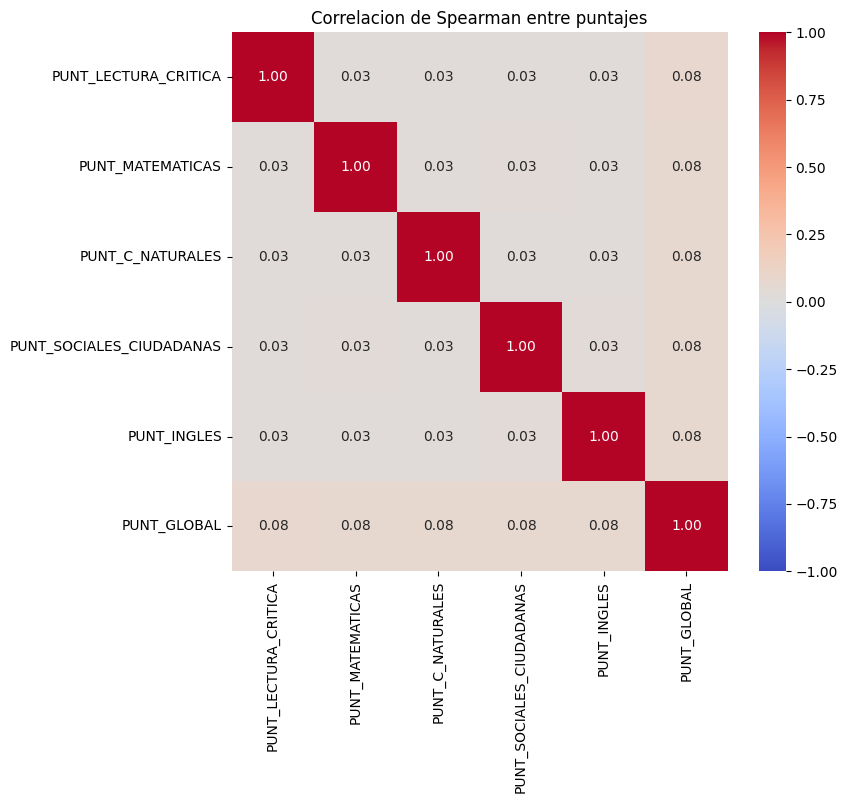

                          PUNT_LECTURA_CRITICA  PUNT_MATEMATICAS  \
PUNT_LECTURA_CRITICA                     1.000             0.031   
PUNT_MATEMATICAS                         0.031             1.000   
PUNT_C_NATURALES                         0.030             0.030   
PUNT_SOCIALES_CIUDADANAS                 0.029             0.032   
PUNT_INGLES                              0.030             0.031   
PUNT_GLOBAL                              0.079             0.077   

                          PUNT_C_NATURALES  PUNT_SOCIALES_CIUDADANAS  \
PUNT_LECTURA_CRITICA                 0.030                     0.029   
PUNT_MATEMATICAS                     0.030                     0.032   
PUNT_C_NATURALES                     1.000                     0.028   
PUNT_SOCIALES_CIUDADANAS             0.028                     1.000   
PUNT_INGLES                          0.031                     0.032   
PUNT_GLOBAL                          0.078                     0.076   

                  

In [6]:
# TODO Parte A: matriz de correlacion Spearman + heatmap
corr_spearman = df[PUNTAJES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlacion de Spearman entre puntajes")
plt.show()

# Interpretacion: las correlaciones ENTRE areas (sin contar PUNT_GLOBAL) son
# todas muy bajas, entre 0.028 y 0.032 -- practicamente no hay relacion entre
# como le va a un estudiante en una materia y como le va en otra. El par mas alto
# (aunque por muy poquito) es MATEMATICAS con SOCIALES_CIUDADANAS (0.032, empatado
# con SOCIALES_CIUDADANAS e INGLES). No le encuentro mucho sentido curricular a
# que esas sean las mas altas -- la diferencia con las demas parejas es tan chiquita
# que probablemente no signifca nada real, y de nuevo parece que este dataset
# genero cada puntaje de forma bastante independiente entre materias. Lo unico
# que si tiene una correlacion un poco mas visible (~0.076-0.079) es cada area
# con PUNT_GLOBAL, lo cual tiene sentido porque PUNT_GLOBAL se calcula a partir
# de las 5 areas.
print(corr_spearman.round(3))

In [7]:
# TODO Parte B: outliers en PUNT_MATEMATICAS con metodo IQR
Q1 = df["PUNT_MATEMATICAS"].quantile(0.25)
Q3 = df["PUNT_MATEMATICAS"].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR
outliers = df[(df["PUNT_MATEMATICAS"] < limite_inf) | (df["PUNT_MATEMATICAS"] > limite_sup)]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}, limite_inf={limite_inf}, limite_sup={limite_sup}")
print(f"Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")
print(f"  Inferiores: {(df['PUNT_MATEMATICAS'] < limite_inf).sum():,}")
print(f"  Superiores: {(df['PUNT_MATEMATICAS'] > limite_sup).sum():,}")
# Comparacion: hay un poco mas de outliers inferiores (1,505) que superiores (1,430),
# pero estan bastante parejos -- ninguno de los dos lados domina claramente. Eso
# encaja con lo que vimos en la Tarea 2: la distribucion es casi simetrica (asimetria
# cerca de 0), asi que tiene sentido que los outliers tambien se repartan parecido
# entre los dos extremos en vez de acumularse todos de un solo lado.

Q1=38.0, Q3=59.0, IQR=21.0, limite_inf=6.5, limite_sup=90.5
Outliers: 2,935 (0.6%)
  Inferiores: 1,505
  Superiores: 1,430


### Reflexión final

Con los resultados del análisis completo:
1. ¿Cuál es el hallazgo más sorprendente que encontraron en los datos reales del Saber 11?
2. ¿Qué variable del dataset NO usaron hoy y creen que podría revelar algo interesante?

_Respuesta:_

_Respuesta:_

1. Lo mas sorprendente fue que las correlaciones entre las 5 areas del examen son casi cero (0.03 en promedio) -- yo esperaba que un estudiante que le va bien en matematicas tambien tienda a irle bien en las otras materias (como suele pasar en la vida real), pero en este dataset practicamente no hay relacion. Eso, sumado a que las 5 areas tienen casi exactamente la misma media, mediana y desviacion estandar, me hace pensar que los puntajes de este dataset de muestra estan simulados de forma bastante independiente entre materias y no reproducen del todo como se comporta un examen real.

2. No usamos DESEMP_INGLES (el nivel de ingles tipo A1, A2, B1...) ni ESTU_FECHANACIMIENTO. Creo que DESEMP_INGLES podria revelar algo interesante si lo cruzamos con FAMI_EDUCACIONMADRE/PADRE o con el estrato, para ver si el nivel de ingles tiene una brecha socioeconomica todavia mas marcada que el PUNT_GLOBAL (uno esperaria que si, porque el acceso a clases de ingles de calidad suele depender bastante de los recursos de la familia).

---

## Entrega

Guarda este notebook con todos los TODO completados y las respuestas escritas.

**Nombre del archivo:** `02_laboratorio_apellido1_apellido2.ipynb`

**Sube a:** Moodle → Clase 4 → Laboratorio (antes del inicio de la siguiente clase).

> **Para el proyecto (P1):** la misma secuencia de análisis que hicieron hoy sobre Saber 11, aplíquenla esta semana sobre su propio dataset. Ver `03_avance_proyecto.md` para el checklist.